## 1. Setup

In [3]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
import joblib

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 150)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

%matplotlib inline


In [5]:
DATA_PATH = Path('../data/processed/nykaa_campaign_features.csv')

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()


Shape: 55555 rows x 53 columns


,Campaign_ID,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score,Spend,CTR,Conversion_Rate,CPC,CPA,ROAS,CPL,Lead_Rate,Lead_to_Conversion_Rate,Overall_Funnel_Efficiency,Impressions_per_Day,Clicks_per_Day,Leads_per_Day,Conversions_per_Day,Spend_per_Day,Year,Month,Quarter,Day_of_Week,Is_Weekend,Channel_Count,Is_Multichannel,Channel_Email,Channel_Facebook,Channel_Google,Channel_Instagram,Channel_WhatsApp,Channel_YouTube,Campaign_Type_Influencer,Campaign_Type_Paid Ads,Campaign_Type_SEO,Campaign_Type_Social Media,Target_Audience_Premium Shoppers,Target_Audience_Tier 2 City Customers,Target_Audience_Working Women,Target_Audience_Youth,Language_English,Language_Hindi,Language_Tamil,Customer_Segment_Premium Shoppers,Customer_Segment_Tier 2 City Customers,Customer_Segment_Working Women,Customer_Segment_Youth
0,NY-CMP-1000,21,57804,6156,3616,2355,1867515,111.03,6.14,20.98,261475.65,10.649782,38.255361,42.474927,111.03,7.142214,72.310744,58.739441,65.127212,4.074113,2752.571429,293.142857,172.190476,112.142857,12451.221429,2025,4,2,1,0,2,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
1,NY-CMP-1001,18,91801,3321,1971,1357,1046247,180.83,3.26,7.24,245386.31,3.617608,40.861186,73.889283,180.83,4.263673,124.498382,59.349593,68.848300,1.478197,5100.055556,184.500000,109.500000,75.388889,13632.572778,2025,4,2,6,1,1,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0
2,NY-CMP-1002,23,15536,2182,952,755,197055,90.60,1.88,25.03,68403.00,14.044799,34.601283,31.348763,90.60,2.880795,71.851891,43.629698,79.306723,4.859681,675.478261,94.869565,41.391304,32.826087,2974.043478,2025,1,1,1,0,3,1,0,0,1,0,0,1,1,0,0,0,0,0,0,1,1,0,0,0,0,0,0
3,NY-CMP-1003,18,88114,8413,2231,947,376906,249.07,0.60,13.15,235869.29,9.547858,11.256389,28.036288,249.07,1.597944,105.723572,26.518483,42.447333,1.074744,4895.222222,467.388889,123.944444,52.611111,13103.849444,2025,6,2,2,0,3,1,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0
4,NY-CMP-1004,10,96871,3743,2060,1258,518296,228.60,0.80,7.29,287578.80,3.863901,33.609404,76.831098,228.60,1.802275,139.601359,55.036067,61.067961,1.298634,9687.100000,374.300000,206.000000,125.800000,28757.880000,2024,12,4,6,1,2,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,1,0,0


Dropped as redundant (|corr| > 0.85 with another feature): ['CPA', 'Engagement_Score']
Final anomaly-detection feature set: ['CTR', 'Conversion_Rate', 'CPC', 'Spend', 'ROAS']


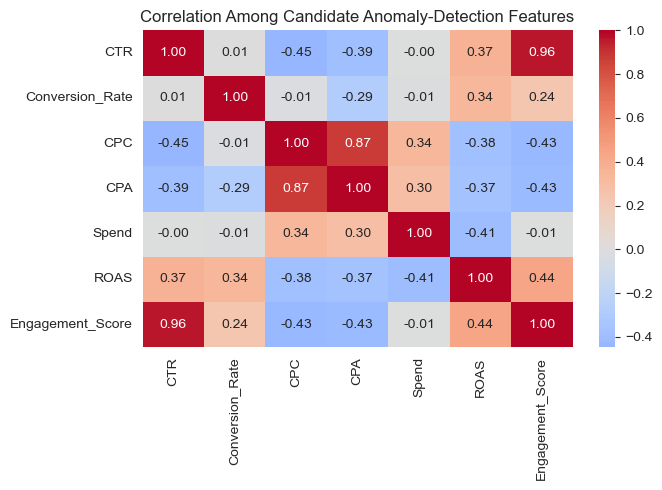

In [7]:
candidate_features = ['CTR', 'Conversion_Rate', 'CPC', 'CPA', 'Spend', 'ROAS', 'Engagement_Score']
candidate_features = [c for c in candidate_features if c in df.columns]
missing = [c for c in ['CTR','Conversion_Rate','CPC','CPA','Spend','ROAS','Engagement_Score']
           if c not in df.columns]
if missing:
    print(f"Note: expected columns not found in this dataset and skipped: {missing}")

corr_matrix = df[candidate_features].corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
redundant = [col for col in upper.columns if any(upper[col] > 0.85)]

anomaly_features = [c for c in candidate_features if c not in redundant]
print(f"Dropped as redundant (|corr| > 0.85 with another feature): {redundant}")
print(f"Final anomaly-detection feature set: {anomaly_features}")

plt.figure(figsize=(7, 5))
sns.heatmap(df[candidate_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Among Candidate Anomaly-Detection Features')
plt.tight_layout()
plt.show()


In [9]:
def robust_zscore(series: pd.Series) -> pd.Series:
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0:
        # Fallback for a feature with a degenerate MAD (many repeated values):
        # use mean absolute deviation instead, so the score doesn't divide by zero.
        mad = (series - median).abs().mean()
    if mad == 0:
        return pd.Series(np.zeros(len(series)), index=series.index)
    return 0.6745 * (series - median) / mad

z_scores = df[anomaly_features].apply(robust_zscore)
z_scores.columns = [f'{c}_z' for c in anomaly_features]

STAT_THRESHOLD = 3.5

z_scores.describe().T


,count,mean,std,min,25%,50%,75%,max
CTR_z,55555.0,0.000114,0.776244,-1.343354,-0.670388,0.0,0.678820,1.339394
Conversion_Rate_z,55555.0,0.167825,0.983716,-1.627460,-0.584367,0.0,0.819657,3.057615
CPC_z,55555.0,0.812310,2.499955,-1.105739,-0.539881,0.0,1.164138,37.859962
Spend_z,55555.0,0.002429,0.781325,-1.348215,-0.672654,0.0,0.676137,1.362011
ROAS_z,55555.0,0.678211,2.067762,-1.015627,-0.551902,0.0,1.098159,33.685359


In [11]:
# direction: 'high' flags only large positive z-scores, 'low' only large negative,
# 'both' flags either direction. These mirror the five example anomaly types the
# assignment itself lists.
ANOMALY_RULES = {
    'CPC':             {'direction': 'high', 'label': 'Sudden increase in CPC'},
    'CTR':              {'direction': 'low',  'label': 'Significant CTR decrease'},
    'Conversion_Rate':  {'direction': 'low',  'label': 'Unexpected conversion drop'},
    'Spend':            {'direction': 'both', 'label': 'Abnormal advertising spend'},
    'ROAS':             {'direction': 'both', 'label': 'Unusual ROAS'},
}
ANOMALY_RULES = {k: v for k, v in ANOMALY_RULES.items() if k in anomaly_features}

def explain_statistical_anomaly(z_row: pd.Series, threshold: float = STAT_THRESHOLD) -> str:
    triggered = []
    for metric, rule in ANOMALY_RULES.items():
        z = z_row.get(f'{metric}_z', 0)
        if rule['direction'] == 'high' and z > threshold:
            triggered.append((abs(z), rule['label']))
        elif rule['direction'] == 'low' and z < -threshold:
            triggered.append((abs(z), rule['label']))
        elif rule['direction'] == 'both' and abs(z) > threshold:
            triggered.append((abs(z), rule['label']))

    if not triggered:
        return 'None'
    triggered.sort(key=lambda t: t[0], reverse=True)
    return '; '.join(label for _, label in triggered)


In [12]:
df['Statistical_Anomaly_Flag'] = (z_scores.abs() > STAT_THRESHOLD).any(axis=1)
df['Statistical_Anomaly_Reason'] = z_scores.apply(explain_statistical_anomaly, axis=1)
df['Statistical_Max_Abs_Z'] = z_scores.abs().max(axis=1)

stat_rate = df['Statistical_Anomaly_Flag'].mean() * 100
print(f"Statistical anomaly rate: {stat_rate:.2f}% ({df['Statistical_Anomaly_Flag'].sum()} campaigns)")

print("\nExample flagged campaigns:")
cols_to_show = ['Campaign_ID'] + anomaly_features + ['Statistical_Anomaly_Reason', 'Statistical_Max_Abs_Z']
cols_to_show = [c for c in cols_to_show if c in df.columns]
df.loc[df['Statistical_Anomaly_Flag'], cols_to_show].sort_values(
    'Statistical_Max_Abs_Z', ascending=False
).head(10)


Statistical anomaly rate: 16.54% (9191 campaigns)

Example flagged campaigns:


,Campaign_ID,CTR,Conversion_Rate,CPC,Spend,ROAS,Statistical_Anomaly_Reason,Statistical_Max_Abs_Z
6807,NY-CMP-7807,2.019923,44.292237,1341.071507,293694.66,0.255633,Sudden increase in CPC,37.859962
49677,NY-CMP-50677,2.148621,23.580786,1228.799476,281395.08,0.137785,Sudden increase in CPC,34.589195
26531,NY-CMP-27531,2.006242,40.444444,1220.912622,274705.34,0.216315,Sudden increase in CPC,34.359431
12007,NY-CMP-13007,14.695978,45.731874,4.152454,60708.88,75.440529,Unusual ROAS,33.685359
2875,NY-CMP-3875,2.457817,12.301587,1188.476032,299495.96,0.069453,Sudden increase in CPC,33.414471
34383,NY-CMP-35383,2.065693,18.018018,1186.117117,263318.00,0.092664,Sudden increase in CPC,33.345750
11272,NY-CMP-12272,2.167363,42.600897,1139.514350,254111.70,0.183561,Sudden increase in CPC,31.988094
33324,NY-CMP-34324,2.433090,7.307692,1130.730923,293990.04,0.047889,Sudden increase in CPC,31.732211
52545,NY-CMP-53545,2.102401,16.379310,1093.469655,253684.96,0.036999,Sudden increase in CPC,30.646696
20956,NY-CMP-21956,2.247562,20.220588,1092.771140,297233.75,0.072536,Sudden increase in CPC,30.626347


In [13]:
print("Breakdown of anomaly reasons (a campaign can trigger more than one):")
reason_counts = (
    df.loc[df['Statistical_Anomaly_Flag'], 'Statistical_Anomaly_Reason']
    .str.split('; ')
    .explode()
    .value_counts()
)
reason_counts


Breakdown of anomaly reasons (a campaign can trigger more than one):


Statistical_Anomaly_Reason
Sudden increase in CPC    4976
Unusual ROAS              4215
Name: count, dtype: int64

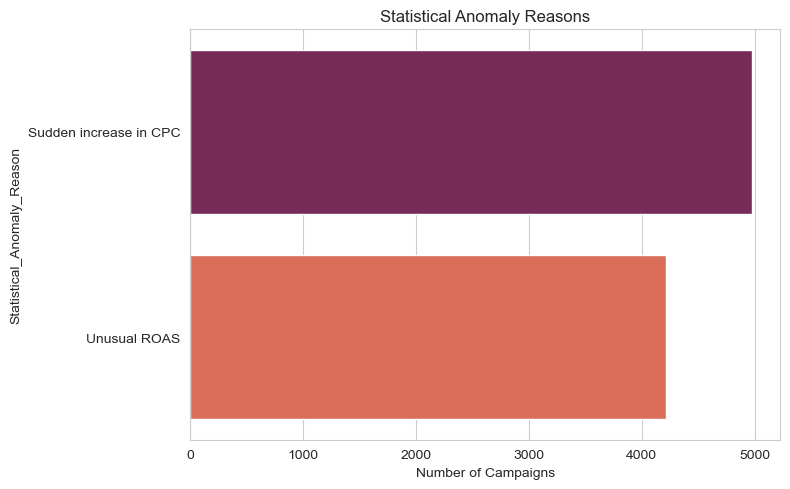

In [14]:
plt.figure(figsize=(8, 5))
sns.barplot(x=reason_counts.values, y=reason_counts.index, palette='rocket')
plt.xlabel('Number of Campaigns')
plt.title('Statistical Anomaly Reasons')
plt.tight_layout()
plt.show()


## 6. Isolation Forest — Multivariate Anomaly Detection

**What:** Fits an `IsolationForest` on the same feature set to catch unusual *combinations* of
metrics that no single-metric rule in Section 5 could flag — e.g. a campaign whose individual
CPC, CTR and ROAS each sit within normal range, but whose specific *combination* of values is
rare.
**Why no feature scaling here, unlike Notebook 6's K-Means:** Isolation Forest isolates points
by recursively splitting on individual feature thresholds (similar to a decision tree) — it
does not use a distance metric, so it is not sensitive to differing feature scales the way
K-Means is. Scaling would be harmless but adds no value, so it's intentionally skipped.
**Why `contamination='auto'`** rather than specifying a fixed anomaly percentage: this uses the
heuristic from the original Isolation Forest paper, derived from the data's own anomaly score
distribution, rather than an arbitrary guessed percentage — a more defensible default than
picking a round number like "5%" without justification.
**Expected output:** the resulting anomaly rate from Isolation Forest, printed alongside the
statistical rate from Section 5 for comparison.

In [16]:
iso_forest = IsolationForest(
    n_estimators=300,
    contamination='auto',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

df['IF_Prediction'] = iso_forest.fit_predict(df[anomaly_features])   # -1 = anomaly, 1 = normal
df['IF_Anomaly_Flag'] = df['IF_Prediction'] == -1

# Isolation Forest's raw score_samples: lower (more negative) = more anomalous.
# Flipping the sign gives an "anomaly score" where higher = more anomalous, which
# is more intuitive to sort and plot.
df['IF_Anomaly_Score'] = -iso_forest.score_samples(df[anomaly_features])

if_rate = df['IF_Anomaly_Flag'].mean() * 100
print(f"Isolation Forest anomaly rate: {if_rate:.2f}% ({df['IF_Anomaly_Flag'].sum()} campaigns)")
print(f"Statistical anomaly rate (Section 5): {stat_rate:.2f}% ({df['Statistical_Anomaly_Flag'].sum()} campaigns)")


Isolation Forest anomaly rate: 22.06% (12257 campaigns)
Statistical anomaly rate (Section 5): 16.54% (9191 campaigns)


## 7. Where the Two Methods Agree — and Where They Don't

**What:** Cross-tabulates the statistical flag against the Isolation Forest flag.
**Why this comparison matters, not just each method's individual rate:** a campaign flagged by
**both** methods is a high-confidence anomaly — two independent approaches agree something is
unusual about it. A campaign flagged by only one method is lower-confidence but still worth a
quick look: Isolation-Forest-only flags are especially interesting, since they represent
multivariate oddities a human scanning single metrics would likely miss entirely.
**Expected output:** a 2×2 agreement table and the resulting four-way campaign counts.

In [18]:
agreement = pd.crosstab(
    df['Statistical_Anomaly_Flag'], df['IF_Anomaly_Flag'],
    rownames=['Statistical Flag'], colnames=['Isolation Forest Flag']
)
print(agreement)

both_flagged = (df['Statistical_Anomaly_Flag'] & df['IF_Anomaly_Flag']).sum()
only_stat = (df['Statistical_Anomaly_Flag'] & ~df['IF_Anomaly_Flag']).sum()
only_if = (~df['Statistical_Anomaly_Flag'] & df['IF_Anomaly_Flag']).sum()

print(f"\nFlagged by both methods (high-confidence): {both_flagged}")
print(f"Flagged by statistical method only: {only_stat}")
print(f"Flagged by Isolation Forest only (multivariate-only pattern): {only_if}")


Isolation Forest Flag  False  True 
Statistical Flag                   
False                  41246   5118
True                    2052   7139

Flagged by both methods (high-confidence): 7139
Flagged by statistical method only: 2052
Flagged by Isolation Forest only (multivariate-only pattern): 5118


In [19]:
df['Anomaly_Confidence'] = np.select(
    [
        df['Statistical_Anomaly_Flag'] & df['IF_Anomaly_Flag'],
        df['Statistical_Anomaly_Flag'] | df['IF_Anomaly_Flag'],
    ],
    ['High (both methods)', 'Medium (one method)'],
    default='None',
)

df['Anomaly_Confidence'].value_counts()


Anomaly_Confidence
None                   41246
Medium (one method)     7170
High (both methods)     7139
Name: count, dtype: int64

## 8. Visualise the Anomalies

**What:** Two scatter plots of commonly-paired metrics (`CPC` vs `CTR`, `Spend` vs `ROAS`),
coloured by `Anomaly_Confidence`, so both the individual-metric extremes and the Isolation
Forest's multivariate flags are visible on the same chart.
**What to look for:** high-confidence points should mostly sit visually apart from the main
cloud of points; "Isolation Forest only" points (not separately highlighted here, but visible
in the full anomaly table above) are the ones worth the closest look, since they're not simply
explained by any single axis on these plots.

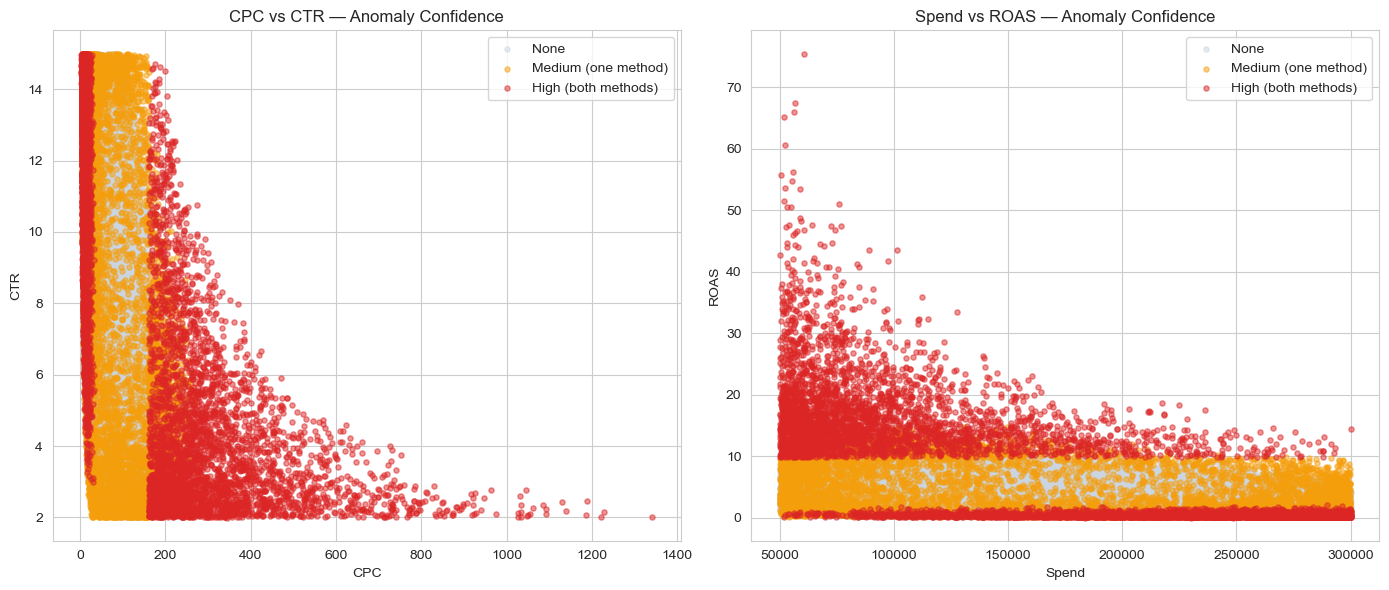

In [21]:
pair_plots = [('CPC', 'CTR'), ('Spend', 'ROAS')]
pair_plots = [(x, y) for x, y in pair_plots if x in df.columns and y in df.columns]

fig, axes = plt.subplots(1, len(pair_plots), figsize=(7 * len(pair_plots), 6))
if len(pair_plots) == 1:
    axes = [axes]

palette = {'None': '#cbd5e1', 'Medium (one method)': '#f59e0b', 'High (both methods)': '#dc2626'}

for ax, (x, y) in zip(axes, pair_plots):
    for level, color in palette.items():
        subset = df[df['Anomaly_Confidence'] == level]
        ax.scatter(subset[x], subset[y], s=14, alpha=0.5, color=color, label=level)
    ax.set_xlabel(x)
    ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y} — Anomaly Confidence')
    ax.legend()

plt.tight_layout()
plt.show()


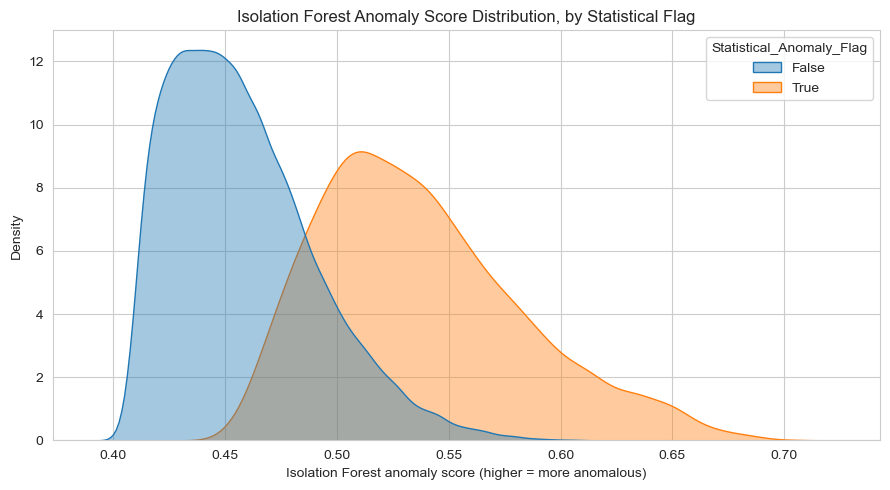

In [22]:
# Distribution of the Isolation Forest anomaly score, split by whether the statistical
# method also flagged the row -- a sanity check that the two methods broadly agree in trend
# even where their binary flags disagree.
plt.figure(figsize=(9, 5))
sns.kdeplot(data=df, x='IF_Anomaly_Score', hue='Statistical_Anomaly_Flag',
            common_norm=False, fill=True, alpha=0.4)
plt.title('Isolation Forest Anomaly Score Distribution, by Statistical Flag')
plt.xlabel('Isolation Forest anomaly score (higher = more anomalous)')
plt.tight_layout()
plt.show()


Isolation Forest anomaly rate (%) by Campaign_Type:


Social Media    22.62
SEO             22.29
Influencer      21.88
Paid Ads        21.64
Name: IF_Anomaly_Flag, dtype: float64

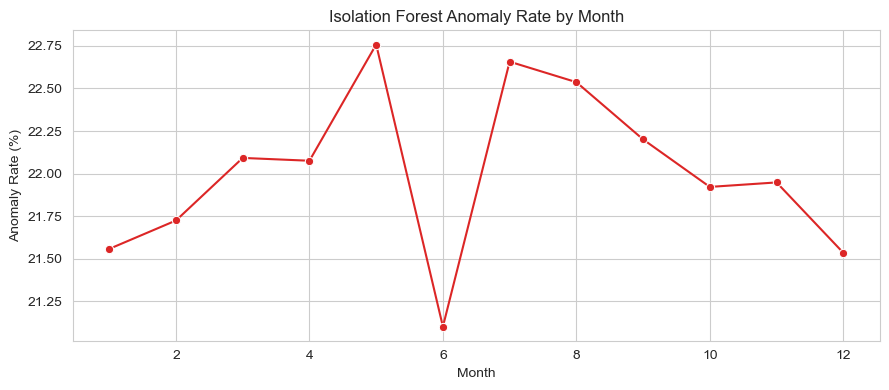

In [24]:
campaign_type_cols = [c for c in df.columns if c.startswith('Campaign_Type_')]

if campaign_type_cols:
    campaign_type_lookup = df[campaign_type_cols].idxmax(axis=1).str.replace('Campaign_Type_', '', regex=False)
    anomaly_by_type = df.groupby(campaign_type_lookup)['IF_Anomaly_Flag'].mean().sort_values(ascending=False) * 100
    print("Isolation Forest anomaly rate (%) by Campaign_Type:")
    display(anomaly_by_type.round(2))
else:
    print("No Campaign_Type_* columns found — skipping this cross-check.")

if 'Month' in df.columns:
    anomaly_by_month = df.groupby('Month')['IF_Anomaly_Flag'].mean().sort_index() * 100
    plt.figure(figsize=(9, 4))
    sns.lineplot(x=anomaly_by_month.index, y=anomaly_by_month.values, marker='o', color='#dc2626')
    plt.xlabel('Month')
    plt.ylabel('Anomaly Rate (%)')
    plt.title('Isolation Forest Anomaly Rate by Month')
    plt.tight_layout()
    plt.show()


In [26]:
OUTPUT_DATA_PATH = Path('../data/processed/nykaa_campaign_anomalies.csv')
df.to_csv(OUTPUT_DATA_PATH, index=False)
print(f"Saved anomaly-flagged dataset to: {OUTPUT_DATA_PATH}")
print(f"Row count unchanged from input: {df.shape[0]} rows (no rows were removed)")

MODELS_DIR = Path('../models')
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(iso_forest, MODELS_DIR / 'anomaly_isolation_forest.joblib')
joblib.dump(anomaly_features, MODELS_DIR / 'anomaly_detection_features.joblib')

print(f"Saved Isolation Forest model and feature list to: {MODELS_DIR}")


Saved anomaly-flagged dataset to: ..\data\processed\nykaa_campaign_anomalies.csv
Row count unchanged from input: 55555 rows (no rows were removed)
Saved Isolation Forest model and feature list to: ..\models
